# Imports

In [1]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [2]:
n = 5
label_name = "stat1"
layers = [2]

epochs = 1000
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [3]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [4]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

Epoch 0, Loss 1.369698941707611
Epoch 1, Loss 1.3915663957595825
Epoch 2, Loss 1.3847398161888123
Epoch 3, Loss 1.368794322013855
Epoch 4, Loss 1.3846129775047302
Epoch 5, Loss 1.3556838631629944
Epoch 6, Loss 1.3578062057495117
Epoch 7, Loss 1.3531152606010437
Epoch 8, Loss 1.3406105637550354
Epoch 9, Loss 1.3328020572662354
Epoch 10, Loss 1.3495823740959167
Epoch 11, Loss 1.3420490622520447
Epoch 12, Loss 1.3571551442146301
Epoch 13, Loss 1.3511823415756226
Epoch 14, Loss 1.3409837484359741
Epoch 15, Loss 1.3397982716560364
Epoch 16, Loss 1.3186801671981812
Epoch 17, Loss 1.3079334497451782
Epoch 18, Loss 1.314961016178131
Epoch 19, Loss 1.3313709497451782
Epoch 20, Loss 1.3080608248710632
Epoch 21, Loss 1.2966413497924805
Epoch 22, Loss 1.27932208776474
Epoch 23, Loss 1.2976297736167908
Epoch 24, Loss 1.263197898864746
Epoch 25, Loss 1.276999056339264
Epoch 26, Loss 1.2898039817810059
Epoch 27, Loss 1.2857252955436707
Epoch 28, Loss 1.276127576828003
Epoch 29, Loss 1.287262618541717

# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

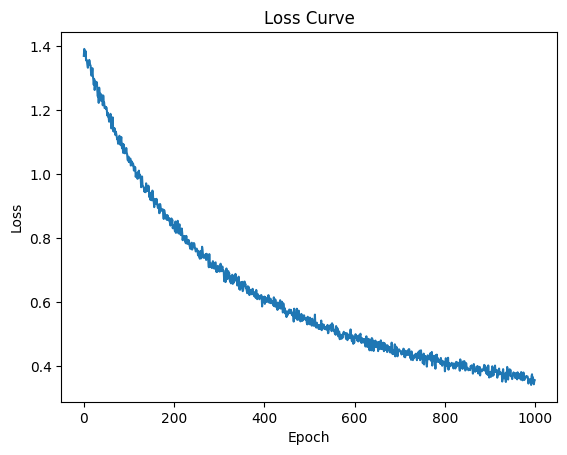

In [5]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')


fig.savefig(f'figures/loss_curve_stat1_{n}.png', dpi=300)
# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [6]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 100.0%
Accuracy for class 1 = 100.0%
Overall accuracy = 100.0%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

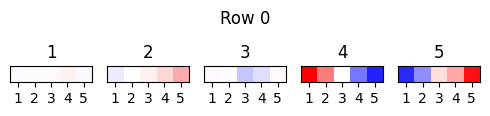

In [7]:
model.plot_heatmap_feature(0,0)